# CNN sobre CIFAR-10 con PyTorch — recurso de la Clase 12

**Módulo 07 — Fundamentos de Deep Learning.** Primera red **convolucional** del curso: clasifica imágenes de CIFAR-10 en 10 categorías.

Es el salto que venían preparando las Clases 8 a 11. Hasta acá las redes eran densas y los datos, tablas de números; a partir de acá la entrada es una **imagen** y aparecen las dos capas nuevas: **convolución** y **agrupamiento**.

> **Kernel:** `Python 3.12 (dl-env)`. La primera corrida descarga CIFAR-10 (~170 MB) en `./train` y `./test`.

## CIFAR-10 en números

| | |
|---|---|
| Imágenes | 60.000 (50.000 train + 10.000 test) |
| Tamaño | 32×32 píxeles, 3 canales de color |
| Clases | 10: avión, auto, pájaro, gato, ciervo, perro, rana, caballo, barco, camión |
| Valores por imagen | 32 × 32 × 3 = **3.072** |

Esos 3.072 valores por imagen son la razón de ser de las CNNs: conectarlos a capas densas desde el arranque daría millones de pesos en una sola capa, y además la red tendría que aprender cada objeto en cada posición por separado.

## La arquitectura de este notebook

```
imagen 32x32x3
  → conv1 (32 filtros) → pool → 16x16
  → conv2 (64 filtros) → pool → 8x8
  → conv3 (128 filtros) → pool → 4x4
  → aplanar (2048 valores)
  → fc1 (512) → fc2 (256) → fc3 (10)
```

Las dos mitades que planteaba la teoría de la Clase 8: **extracción de características** (las convoluciones) y **clasificación** (las densas). Total: **1.276.234 parámetros**.

# CIFAR-10

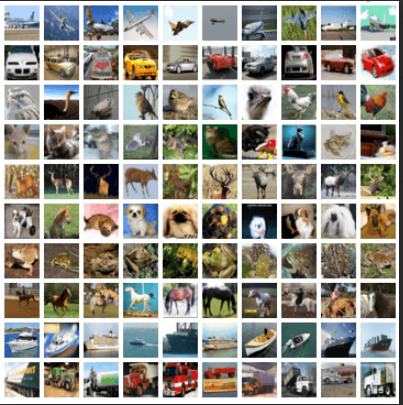


Éstas son las características generales de CIFAR-10:
* Se compone de 60.000 imágenes.
* Cada imagen es 32x32x3, en espacio RGB.
* Hay 50.000 imágenes de entrenamiento.
* Hay 10.000 imágenes de prueba.
* Hay 10 clases, donde cada una está representada por 6.000 imágenes.

Las clases son mutuamente excluyentes (es decir, una misma foto no puede pertenecer a más de una clase). Estas son las 10 clases de CIFAR-10:
* airplane (avión).
* automobile (automóvil).
* bird (ave).
* cat (gato).
* deer (venado).
* dog (perro).
* frog (rana).
* horse (caballo).
* ship (barco).
* truck (camión).

## 1. Librerías

Lo nuevo respecto de los notebooks anteriores:

- **`torch.nn.functional as F`** — versión funcional de las operaciones. `F.relu(x)` hace lo mismo que `nn.ReLU()(x)`, pero se llama directo en el `forward` sin declararla en `__init__`. Es cuestión de estilo: las capas con pesos (`Conv2d`, `Linear`) van en `__init__`; las que no tienen pesos (activaciones) pueden ir como funciones.
- **`torchvision`** — la biblioteca de PyTorch para visión: trae datasets listos (CIFAR-10 entre ellos), transformaciones y modelos pre-entrenados.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## 2. Cargar y transformar CIFAR-10

**`transforms.Compose`** encadena dos transformaciones que se aplican a cada imagen:

| Transformación | Qué hace |
|---|---|
| `ToTensor()` | Convierte la imagen (PIL) en tensor y **escala los píxeles de 0-255 a 0-1**, reordenando a `(canales, alto, ancho)` |
| `Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))` | Resta 0,5 y divide por 0,5 en cada canal: lleva el rango de **[0, 1] a [−1, 1]** |

Los dos tríos de `Normalize` son la **media** y el **desvío** por canal (rojo, verde, azul). Con 0,5 y 0,5 el resultado queda centrado en cero, que es lo que conviene para el entrenamiento — la misma idea del `StandardScaler` de los notebooks anteriores, adaptada a imágenes.

> Con datasets reales suelen usarse la media y el desvío calculados sobre el propio dataset. Para CIFAR-10 los valores habituales son `(0.4914, 0.4822, 0.4465)` y `(0.2470, 0.2435, 0.2616)`. Los 0,5 son una simplificación cómoda.

**`download=True`** baja el dataset la primera vez (~170 MB) y lo reutiliza después. **`num_workers=2`** usa dos procesos en paralelo para preparar los lotes mientras la GPU entrena.

Con `batch_size=8` y 50.000 imágenes de train salen **6.250 lotes por época**.

In [2]:
import torch.utils

batch_size = 8

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root= './train', train=True, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size= batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root= './test', train=False, download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size= batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170498071/170498071 [00:02<00:00, 72121340.78it/s]


Extracting ./train/cifar-10-python.tar.gz to ./train


100%|██████████| 170498071/170498071 [00:03<00:00, 49912670.45it/s]


Extracting ./test/cifar-10-python.tar.gz to ./test


## 3. Función para mostrar imágenes

`img / 2 + 0.5` es la operación **inversa** de `Normalize`: devuelve los valores de [−1, 1] a [0, 1] para poder mostrarlos.

`np.transpose(npimg, (1, 2, 0))` reordena los ejes. PyTorch guarda las imágenes como `(canales, alto, ancho)` y matplotlib las espera como `(alto, ancho, canales)`; esta línea hace la traducción.

In [3]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

## 4. Ver un lote de ejemplo

`iter(trainloader)` + `next(...)` toma el primer lote, que son 8 imágenes con sus etiquetas.

Mirar los datos antes de entrenar no es un trámite: CIFAR-10 son imágenes de 32×32, lo bastante chicas como para que a simple vista cueste distinguir un gato de un perro. Eso ayuda a calibrar qué exactitud es razonable esperar.

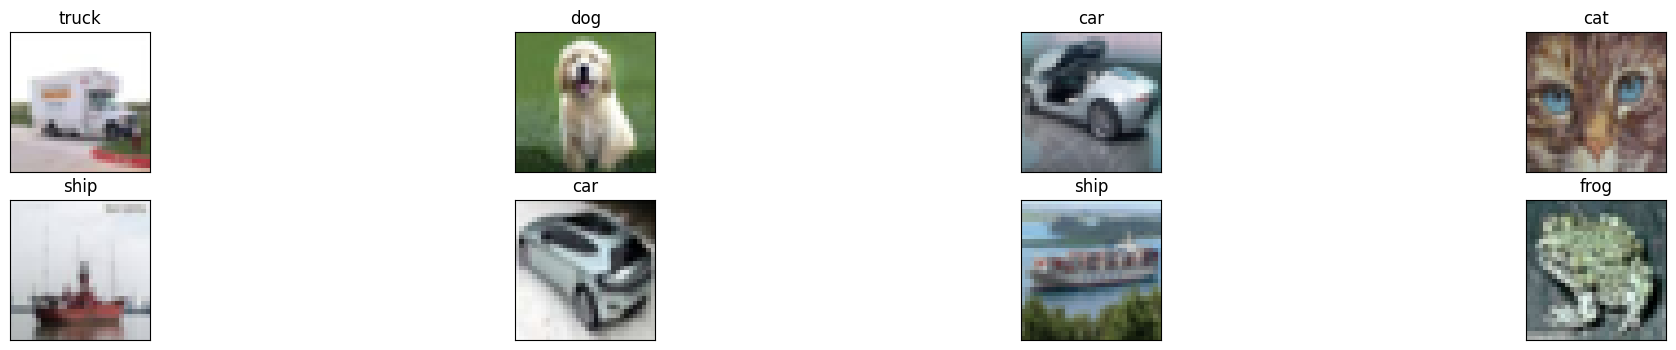

In [4]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(25, 4))

for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, 4, idx + 1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

## 5. Definir la CNN

Igual que antes, una clase que hereda de `nn.Module`. Lo nuevo son las capas.

**`nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)`**

| Capa | Entrada → salida | Qué significa |
|---|---|---|
| `conv1` | 3 → 32 canales | Los 3 canales de color entran; salen **32 mapas de características**, uno por filtro |
| `conv2` | 32 → 64 | Cada filtro combina los 32 mapas anteriores |
| `conv3` | 64 → 128 | Más filtros a medida que la imagen se achica |

Los parámetros de cada convolución:

- **`kernel_size=3`** — el filtro es una ventana de 3×3 que recorre la imagen.
- **`stride=1`** — se desplaza de a un píxel.
- **`padding=1`** — agrega un borde de un píxel alrededor. Con kernel 3 y stride 1, ese padding hace que **la salida mantenga el tamaño de la entrada**. Sin él, cada convolución achicaría la imagen 2 píxeles.

**`nn.MaxPool2d(kernel_size=2, stride=2)`** — toma el máximo de cada ventana de 2×2 sin solaparse, así que **divide alto y ancho por dos**. Es lo que reduce la imagen y hace que la red se vuelva menos sensible a la posición exacta.

**De dónde sale el `128 * 4 * 4`**, que es el número que suele confundir:

| Etapa | Tamaño |
|---|---|
| Entrada | 32×32 |
| conv1 (padding 1, no cambia) → pool | **16×16** |
| conv2 → pool | **8×8** |
| conv3 → pool | **4×4** |

Al final quedan 128 mapas de 4×4 = **2.048 valores**, que es lo que recibe `fc1`. Si se cambia la cantidad de convoluciones o el tamaño de entrada, este número cambia y hay que recalcularlo a mano — es la fuente de error más común al armar una CNN en PyTorch.

**`x.view(-1, 128 * 4 * 4)`** es el **aplanamiento** (*flattening*) del que hablaba la Clase 10: convierte los mapas en un vector para que puedan entrar a las capas densas. El `-1` deja que PyTorch infiera el tamaño del lote.

**`fc3` no lleva activación**, como siempre que se usa `CrossEntropyLoss`.

In [5]:
class CNN_Model(nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.fc1 = nn.Linear(128 * 4 * 4, 512)

        self.fc2 = nn.Linear(512, 256)

        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))


        x = self.pool(F.relu(self.conv2(x)))


        x = self.pool(F.relu(self.conv3(x)))


        x = x.view(-1, 128 * 4 * 4)

        x = F.relu(self.fc1(x))


        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x

## 6. Ver la estructura

`print(model)` lista las capas declaradas en `__init__` con sus parámetros. Notar que muestra `fc1: in_features=2048`, que es el `128 * 4 * 4` ya calculado.

Lo que **no** muestra es el `forward`: el orden real en que se aplican las capas. Dos modelos con el mismo `__init__` pueden hacer cosas distintas.

In [6]:
model = CNN_Model()
print(model)

CNN_Model(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


## 7. `torchsummary` — el equivalente a `model.summary()`

Acá aparece la biblioteca que el curso hizo instalar en la Clase 2. Muestra lo que `print(model)` no dice: **la forma de la salida de cada capa** y cómo se van repartiendo los parámetros.

| Capa | Salida | Parámetros |
|---|---|---:|
| Conv2d-1 | [8, 32, 32, 32] | 896 |
| MaxPool2d-2 | [8, 32, 16, 16] | 0 |
| Conv2d-3 | [8, 64, 16, 16] | 18.496 |
| MaxPool2d-4 | [8, 64, 8, 8] | 0 |
| Conv2d-5 | [8, 128, 8, 8] | 73.856 |
| MaxPool2d-6 | [8, 128, 4, 4] | 0 |
| Linear-7 | [8, 512] | **1.049.088** |
| Linear-8 | [8, 256] | 131.328 |
| Linear-9 | [8, 10] | 2.570 |
| | **Total** | **1.276.234** |

**Dos cosas que vale leer de esta tabla:**

1. **El pooling no tiene parámetros.** Es una operación fija —tomar el máximo—, no algo que se aprenda. Por eso su columna es 0.
2. **La primera capa densa se lleva el 82% de los parámetros** (1.049.088 de 1.276.234). Las tres convoluciones juntas suman apenas 93.248. Ahí se ve el argumento entero de las CNNs: un filtro de 3×3 tiene 9 pesos que se reutilizan en toda la imagen, mientras que una capa densa necesita un peso por cada conexión. Las convoluciones hacen el trabajo pesado con una fracción de los parámetros.

La progresión de tamaños también es característica: la imagen se achica (32 → 16 → 8 → 4) mientras la cantidad de canales crece (3 → 32 → 64 → 128). Se pierde resolución espacial y se gana abstracción.

In [7]:
from torchsummary import summary
summary(model, input_size=images.shape[1:], batch_size=batch_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [8, 32, 32, 32]             896
         MaxPool2d-2            [8, 32, 16, 16]               0
            Conv2d-3            [8, 64, 16, 16]          18,496
         MaxPool2d-4              [8, 64, 8, 8]               0
            Conv2d-5             [8, 128, 8, 8]          73,856
         MaxPool2d-6             [8, 128, 4, 4]               0
            Linear-7                   [8, 512]       1,049,088
            Linear-8                   [8, 256]         131,328
            Linear-9                    [8, 10]           2,570
Total params: 1,276,234
Trainable params: 1,276,234
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.09
Forward/backward pass size (MB): 4.42
Params size (MB): 4.87
Estimated Total Size (MB): 9.38
---------------------------------------

## 8. Pérdida y optimizador

**`CrossEntropyLoss`** para clasificación multiclase, igual que antes.

**`SGD` con `momentum=0.9`**, en lugar del Adam de los notebooks anteriores. El *momentum* acumula la dirección de los pasos previos: acelera cuando el gradiente apunta consistentemente hacia el mismo lado y amortigua el zigzag. Sin él, SGD con `lr=0.001` avanzaría muy lento.

> Es la configuración clásica de los tutoriales de PyTorch. El notebook de TensorFlow de la Clase 13 usa **Adam** sobre la misma arquitectura, y eso explica buena parte de la diferencia de resultados entre los dos.

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

## 9. Entrenamiento

El mismo bucle de cinco pasos de siempre — `zero_grad`, forward, loss, `backward`, `step` — pero ahora sobre 6.250 lotes por época.

`enumerate(trainloader, 0)` numera los lotes, y el bloque `if i % 2000 == 1999` imprime el promedio de la pérdida **cada 2.000 lotes** en lugar de una vez por época. Con lotes tan chicos, esperar al final de la época daría muy poca información.

En el output se ve la pérdida bajando de 2,255 a 1,188 a lo largo de las dos épocas. Como referencia, con 10 clases el azar da una pérdida cercana a `ln(10) ≈ 2,30`: el primer valor impreso está prácticamente ahí, así que la red arrancó sin saber nada.

> **Solo 2 épocas.** Es poco: la pérdida sigue bajando con claridad al final del entrenamiento. Está así para que el notebook corra rápido en clase, no porque el modelo haya convergido.

In [9]:
for epoch in range(2):

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):

        inputs, labels = data

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.255
[1,  4000] loss: 1.853
[1,  6000] loss: 1.572
[2,  2000] loss: 1.391
[2,  4000] loss: 1.286
[2,  6000] loss: 1.188
Finished Training


## 10. Exactitud global

`torch.no_grad()` desactiva el cálculo de gradientes, que no hacen falta para predecir.

**Resultado: 58,85%.** Con 10 clases balanceadas, el azar daría 10%, así que la red aprendió bastante — pero está lejos de ser buena. Con más épocas y algunos ajustes, esta misma arquitectura supera el 70%.

In [10]:
correct = 0
total = 0

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network: {100 * correct / total: .2f}%')


Accuracy of the network:  58.85%


## 11. Exactitud por clase

Este desglose es más informativo que el número global, y muestra que el modelo es **muy desparejo**:

| Clase | Exactitud | |
|---|---:|---|
| plane | 76,9% | mejor |
| frog | 73,2% | |
| car | 70,1% | |
| horse | 67,0% | |
| dog | 63,4% | |
| ship | 60,8% | |
| truck | 53,9% | |
| bird | 51,0% | |
| cat | 44,3% | |
| **deer** | **38,7%** | peor |

El patrón tiene sentido: los objetos **artificiales** (avión, auto, barco, camión) tienen formas rígidas y fondos característicos —cielo, ruta, agua—, mientras que los **animales** (ciervo, gato, pájaro) aparecen en poses variadas, sobre fondos naturales y se parecen entre sí. Ciervo y gato son las dos peores, y no sorprende: en 32×32 píxeles, un ciervo sobre pasto y un perro sobre pasto comparten muchísimo.

Un promedio de 58,85% oculta que el modelo casi acierta 8 de cada 10 aviones y menos de 4 de cada 10 ciervos.

In [ ]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predictions = torch.max(outputs.data, 1)

        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')


Accuracy for class: plane is 76.9 %
Accuracy for class: car   is 70.1 %
Accuracy for class: bird  is 51.0 %
Accuracy for class: cat   is 44.3 %
Accuracy for class: deer  is 38.7 %
Accuracy for class: dog   is 63.4 %
Accuracy for class: frog  is 73.2 %
Accuracy for class: horse is 67.0 %
Accuracy for class: ship  is 60.8 %
Accuracy for class: truck is 53.9 %


## 12. Predicciones sobre imágenes reales

La última celda muestra 8 imágenes del test con dos etiquetas: la predicha y, entre paréntesis, la real. El título va en **verde si acertó y en rojo si erró**.

Es el cierre natural del notebook: después de los números agregados, ver los casos concretos. Con una exactitud del 59% es esperable que dos o tres de las ocho estén en rojo, y mirarlas suele explicar mucho más que la métrica — se ve qué confundió el modelo y si el error era razonable.

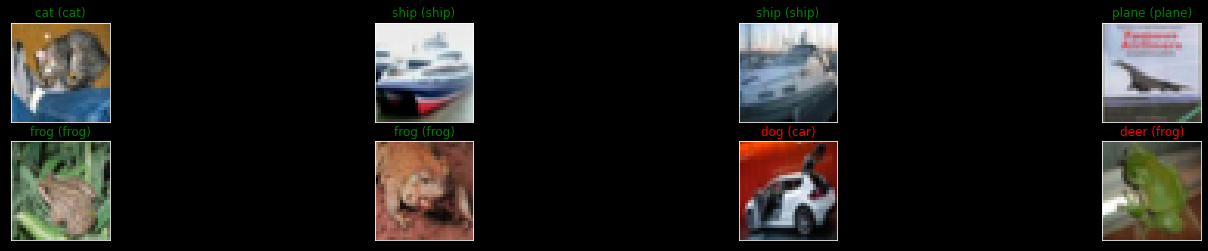

In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

output = model(images)

_, preds_tensor = torch.max(output.data, 1)
preds = np.squeeze(preds_tensor.numpy())

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(8):
    ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=("green" if preds[idx]==labels[idx].item() else "red"))


---

## Resumen

### Lo nuevo de este notebook

Todo lo anterior del módulo trabajaba con datos tabulares y capas densas. Acá aparecen las dos operaciones que definen una CNN:

| Capa | Qué hace | Parámetros |
|---|---|---|
| **`Conv2d`** | Desliza filtros de 3×3 sobre la imagen y produce mapas de características | 9 pesos por filtro y canal, reutilizados en toda la imagen |
| **`MaxPool2d`** | Toma el máximo de cada ventana 2×2, reduce a la mitad | **ninguno** — es una operación fija |

Y una tercera pieza, el **aplanamiento** (`x.view(-1, 2048)`), que hace de puente entre la parte convolucional y las capas densas.

### La cuenta del `128 * 4 * 4`

| Etapa | Tamaño espacial |
|---|---|
| Entrada | 32×32 |
| tras conv1 + pool | 16×16 |
| tras conv2 + pool | 8×8 |
| tras conv3 + pool | 4×4 |

128 canales × 4 × 4 = **2.048**. Con `padding=1` las convoluciones no cambian el tamaño; **el que divide por dos es el pooling**. Cambiar la cantidad de bloques o el tamaño de entrada obliga a recalcular este número a mano: es el error más frecuente al armar una CNN en PyTorch, y no da un mensaje claro cuando falla.

### Dónde están los parámetros

| Bloque | Parámetros | % |
|---|---:|---:|
| Las 3 convoluciones | 93.248 | 7% |
| Las 3 densas | 1.182.986 | **93%** |

**La primera capa densa sola tiene 1.049.088**, más de diez veces todas las convoluciones juntas. Es el argumento entero de las CNNs en un número: las convoluciones extraen las características con pocos pesos porque los **reutilizan en toda la imagen**; las densas necesitan un peso por conexión.

### Los resultados, y qué esperar

- **58,85%** global con 2 épocas. El azar sería 10%.
- Por clase va de **76,9%** (avión) a **38,7%** (ciervo). Los objetos artificiales se reconocen mucho mejor que los animales.
- La pérdida **seguía bajando** al terminar: 2 épocas es poco. No es que el modelo haya llegado a su techo.

### Detalles de PyTorch que aparecen acá por primera vez

- **`F.relu`** en lugar de declarar `nn.ReLU()` — las operaciones sin pesos pueden ir como funciones en el `forward`.
- **`transforms.Compose`** para encadenar transformaciones, y `Normalize` con media y desvío por canal.
- **`num_workers`** en el `DataLoader`, para preparar lotes en paralelo.
- **`torchsummary`** para ver formas y parámetros por capa, que es lo que Keras da con `model.summary()`.
- **SGD con momentum** en lugar de Adam.

### Comparación con la versión en TensorFlow

El recurso de la Clase 13 implementa **la misma arquitectura** en Keras. Vale leerlos juntos: misma cantidad de parámetros (1.276.234), pero distinto optimizador y distinta normalización, y por eso distinto resultado. La comparación completa está en ese notebook.